 # Health Insurance Price prediction

Many factors that affect how much you pay for health insurance are not within your control. Nonetheless, it's good to have an understanding of what they are. Here are some factors that affect how much health insurance premiums cost

age: age of primary beneficiary

sex: insurance contractor gender, female, male

bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

children: Number of children covered by health insurance / Number of dependents

smoker: Smoking

region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape


(1338, 7)

In [4]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [6]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

We have 0 missing values which is very good. Now let's do EDA with some cool graphs :) First we'll see how the charges are distributed according to given factors

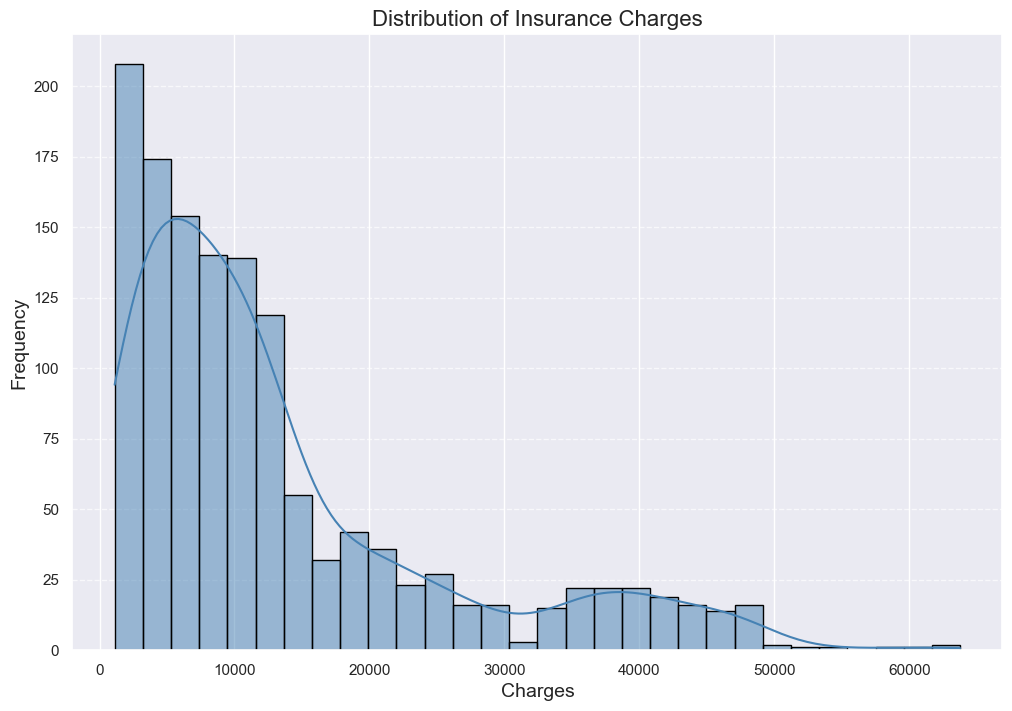

In [7]:
sns.set_theme(style='darkgrid')
f, ax = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.histplot(df['charges'], kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Insurance Charges', fontsize=16)
plt.xlabel('Charges', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


This distribution is right-skewed. To make it closer to normal we can apply natural log



This transformation is commonly applied when dealing with right-skewed distributions. Here's an explanation of why:

Symmetry: Applying the natural logarithm to a right-skewed distribution can help make the distribution more symmetric. Right-skewed distributions often have a long right tail, and taking the logarithm tends to compress the larger values, pulling in the tail and making the distribution more symmetric.

Stabilizing Variances: In some cases, taking the logarithm can stabilize the variances across different levels of the independent variable. This can be beneficial in statistical modeling, especially when you're dealing with data where the spread of values increases with the level of the independent variable.

Interpretability: When interpreting results in the context of linear models, taking the logarithm can make the effects of predictor variables more interpretable. For instance, in a linear regression, the coefficient for a variable after a log transformation represents the percentage change in the dependent variable for a one-unit change in the predictor.

Normality: Transforming data with the natural logarithm can also make the distribution more normal or close to normal. This can be advantageous in statistical analyses that assume normality, such as certain parametric tests or linear regression.

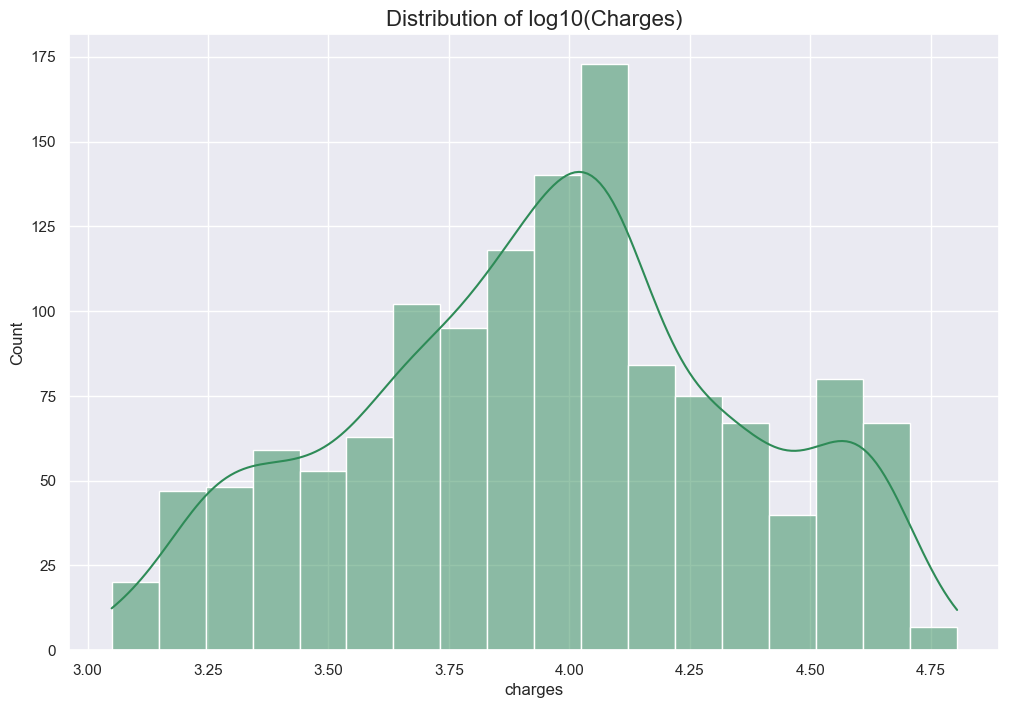

In [8]:
f, ax = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.histplot(np.log10(df['charges']), kde=True, color='seagreen')
plt.title('Distribution of log10(Charges)', fontsize=16)
plt.show()

Now let's look at the charges by region



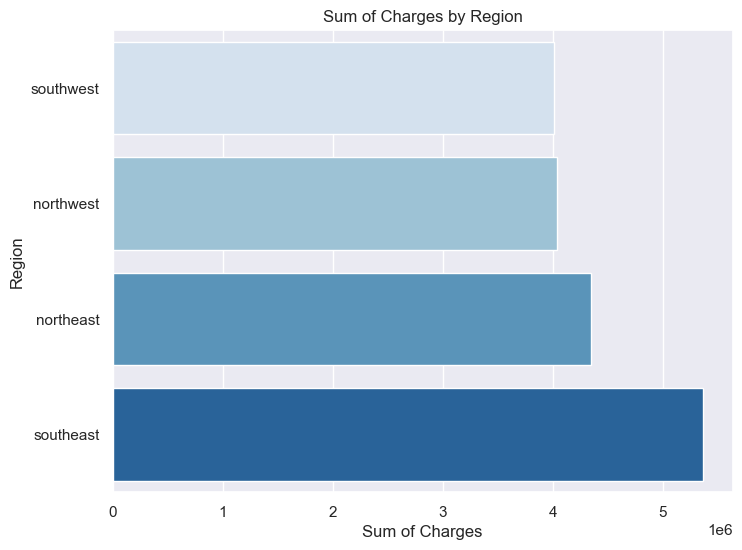

In [9]:
charges = df['charges'].groupby(df.region).sum().sort_values(ascending=True)
f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax = sns.barplot(x=charges.values, y=charges.index, hue=charges.index, palette='Blues', legend=False)
plt.xlabel('Sum of Charges')
plt.ylabel('Region')
plt.title('Sum of Charges by Region')
plt.show()

In [10]:
charges

region
southwest    4.012755e+06
northwest    4.035712e+06
northeast    4.343669e+06
southeast    5.363690e+06
Name: charges, dtype: float64

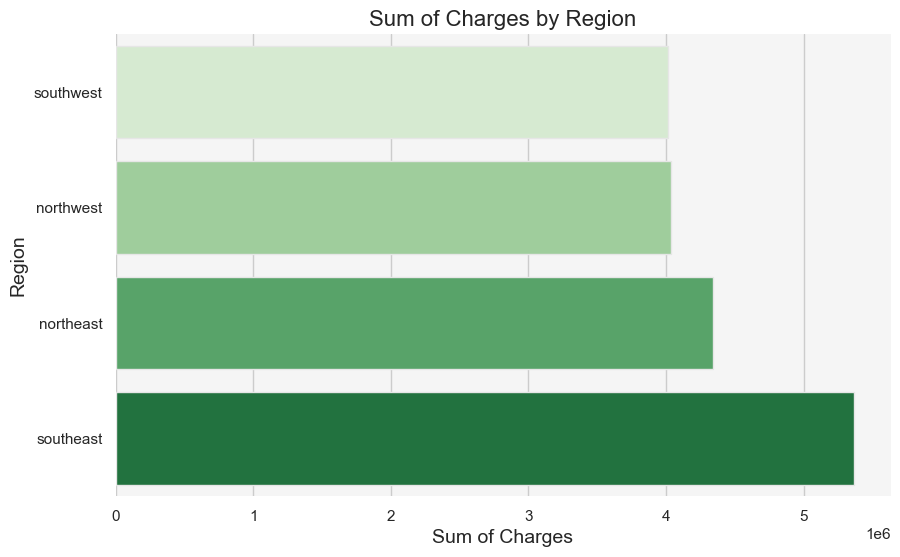

In [11]:
sns.set_theme(style='whitegrid')

charges = df['charges'].groupby(df['region']).sum().sort_values(ascending=True)

color_palette = sns.color_palette("Greens", len(charges))

f, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(x=charges.values, y=charges.index, hue=charges.index,
                 palette=color_palette, edgecolor=".9", legend=False)

# Adding labels and title with a larger font size
plt.xlabel('Sum of Charges', fontsize=14)
plt.ylabel('Region', fontsize=14)
plt.title('Sum of Charges by Region', fontsize=16)

# Set a background color for the plot
ax.set_facecolor("#f5f5f5")

# Add a shadow to the plot for a raised effect
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)
ax.spines['left'].set_linewidth(0)

plt.show()


So overall the highest medical charges are in the Southeast and the lowest are in the Southwest. Taking into account certain factors (sex, smoking, having children) let's see how it changes by region



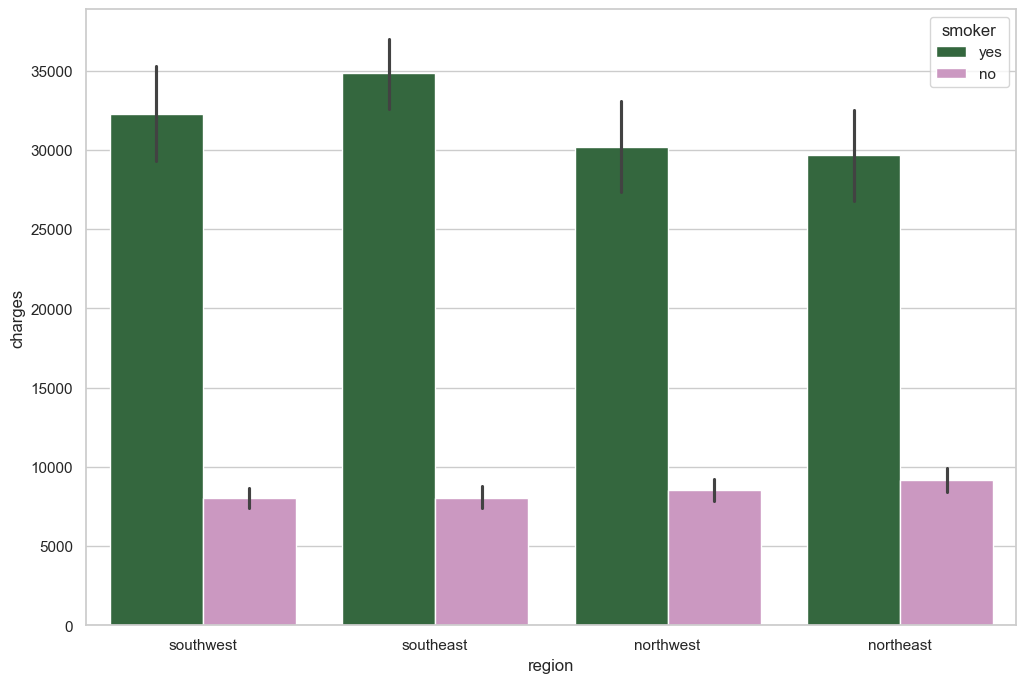

In [12]:
f, ax = plt.subplots(1,1, figsize=(12,8))
ax = sns.barplot(x = 'region', y = 'charges',
                 hue='smoker', data=df, palette='cubehelix')

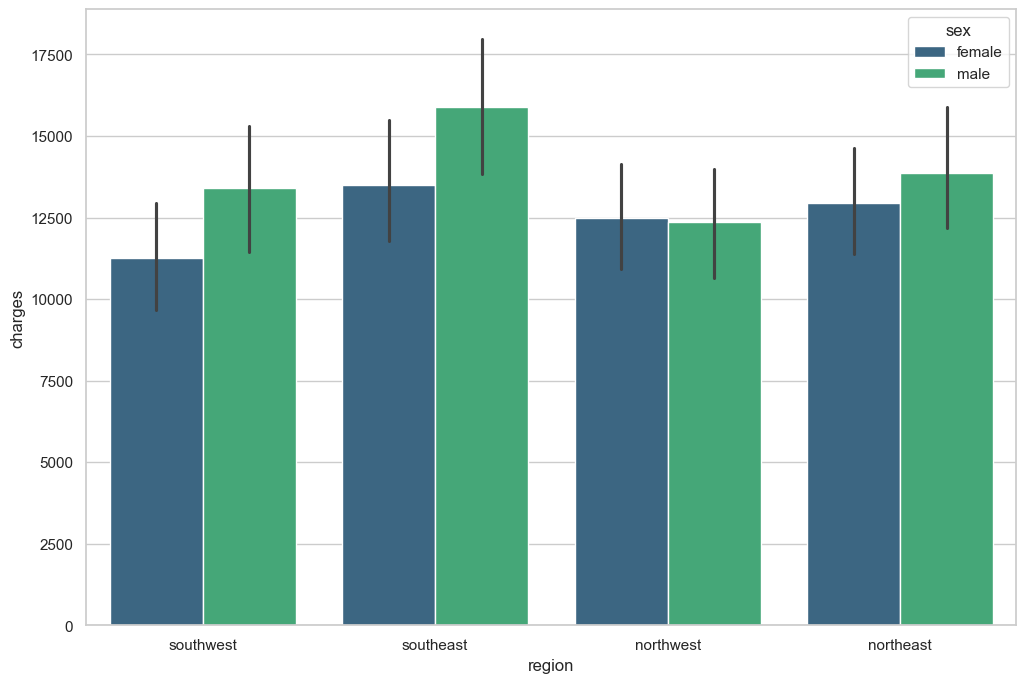

In [13]:
f, ax = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(x='region', y='charges', hue='sex', data=df, palette='viridis')

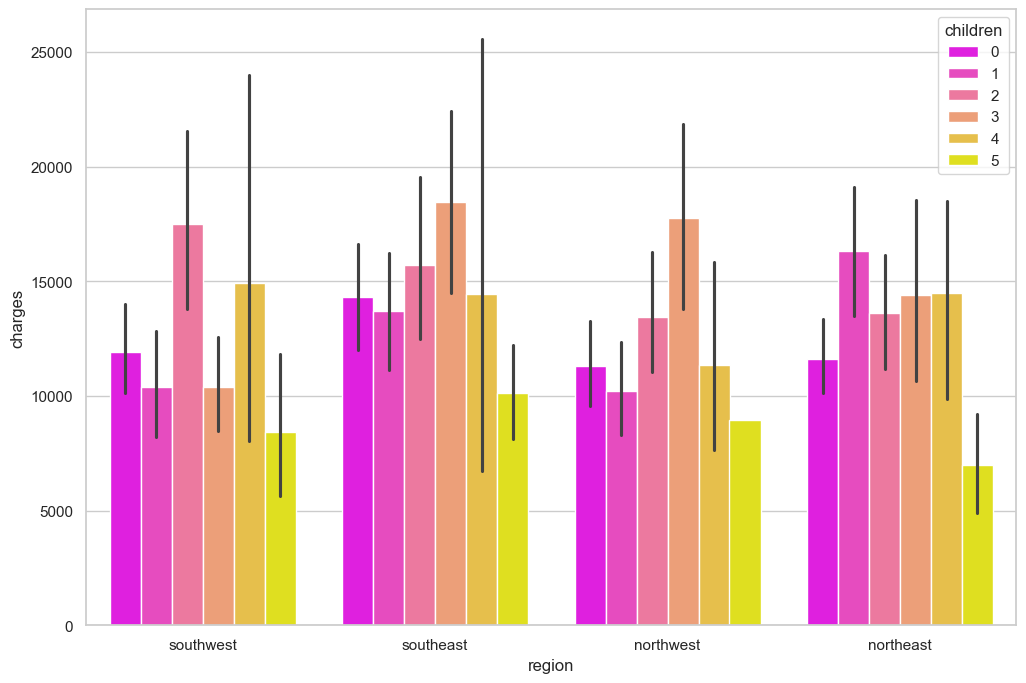

In [14]:
f, ax = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(x='region', y='charges', hue='children', data=df, palette='spring')

Observing the bar plots, it is evident that the Southeast region exhibits the highest medical charges attributable to smoking, while the Northeast region demonstrates the lowest. Notably, individuals in the Southwest display a higher prevalence of smoking compared to those in the Northeast. However, despite higher smoking rates, individuals in the Northeast exhibit greater medical charges by gender when compared to those in the Southwest and Northwest regions collectively. Additionally, there is a discernible trend indicating that individuals with dependents tend to incur elevated medical expenses overall.

## Analysing the medical charges by age, bmi and children according to the smoking factor



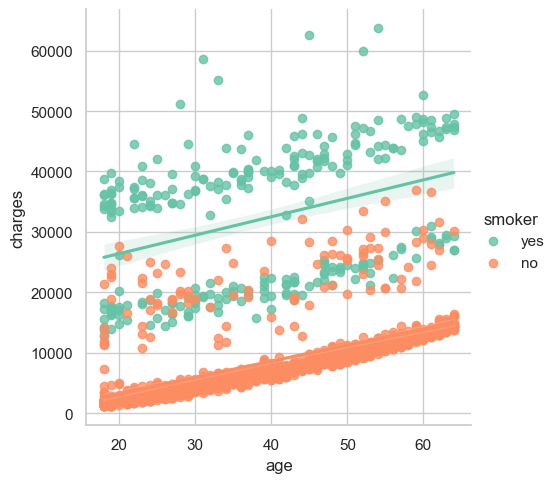

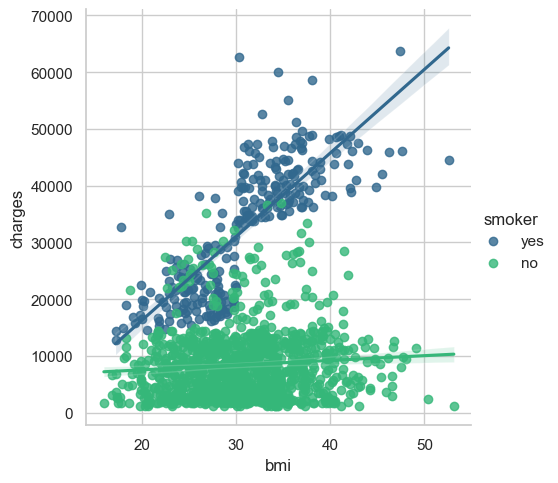

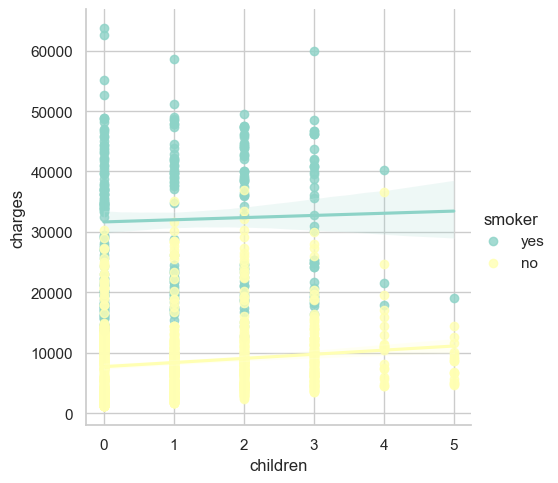

In [15]:
ax = sns.lmplot(x = 'age', y = 'charges', data=df, hue='smoker', palette='Set2')
ax = sns.lmplot(x = 'bmi', y = 'charges', data=df, hue='smoker', palette='viridis')
ax = sns.lmplot(x = 'children', y = 'charges', data=df, hue='smoker', palette='Set3')

Smoking has the highest impact on medical costs, even though the costs are growing with age, bmi and children. Also people who have children generally smoke less, which the following violinplots shows too



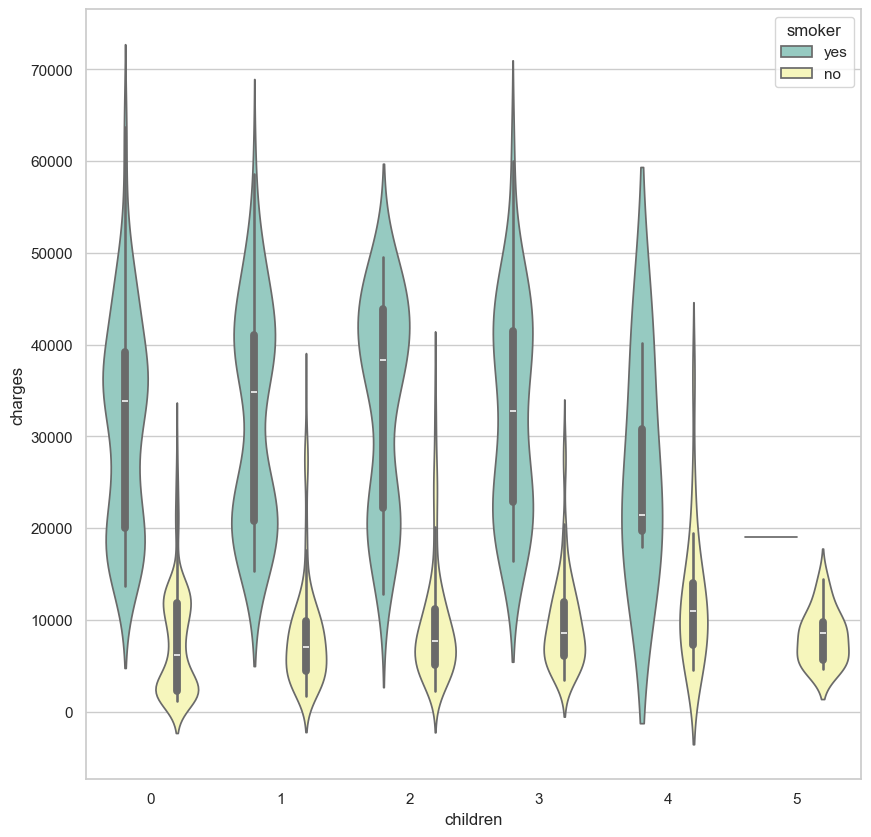

In [16]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax = sns.violinplot(x = 'children', y = 'charges', data=df,
                 orient='v', hue='smoker', palette='Set3')

The violin plot created using Seaborn depicts the distribution of medical charges in relation to the number of children an individual has, with a further breakdown based on smoking status. The horizontal axis represents the number of children (from 0 to a higher count), while the vertical axis represents the corresponding medical charges. The width of each violin plot at a given number of children reflects the density of data points, with wider sections indicating higher concentration. The plot is split into different hues, representing smokers and non-smokers, enabling a visual comparison of their respective distributions. The violin plot reveals insights into the variability and central tendency of medical charges across different child counts and smoking categories, providing a comprehensive view of the data distribution and potential relationships between the variables.

In [17]:
##Converting objects labels into categorical
df[['sex', 'smoker', 'region']] = df[['sex', 'smoker', 'region']].astype('category')
df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

In [18]:
# One-hot encode the categorical columns so we can compute a correlation matrix.
# One-hot encoding (each category becomes its own 0/1 column) avoids imposing a
# fake ordinal relationship the way label encoding would (e.g. northeast=0 <
# northwest=1 < southeast=2 has no real meaning).
#
# Note: this encoded frame is only used for the heatmap below. The models in the
# next section apply the same encoding *inside* a scikit-learn Pipeline, so it is
# re-fit on each training fold and never sees test data.
df_model = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


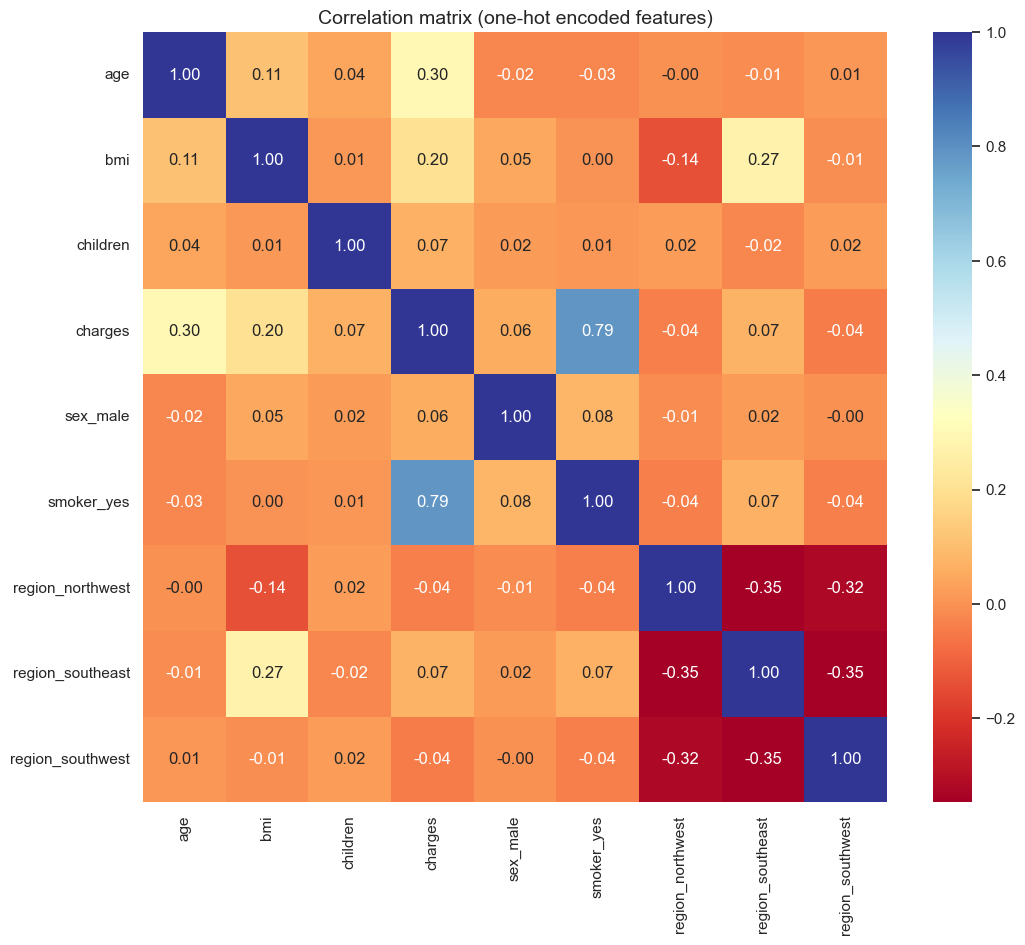

In [19]:
f, ax = plt.subplots(1, 1, figsize=(12, 10))
ax = sns.heatmap(df_model.corr(), annot=True, fmt='.2f', cmap='RdYlBu')
plt.title('Correlation matrix (one-hot encoded features)', fontsize=14)
plt.show()

# Regression Model Comparison

We compare five models, from simplest to most flexible:

- **Linear Regression** — the baseline. Assumes charges are a weighted sum of the features. Fast and fully interpretable, but it cannot capture interactions (e.g. smoking amplifying the effect of BMI).
- **Ridge Regression** — linear regression plus an **L2 penalty** that shrinks coefficients toward zero. Helps when features are correlated or the model overfits. The penalty strength `alpha` is a hyperparameter that must be tuned.
- **Lasso Regression** — linear regression plus an **L1 penalty**. Unlike Ridge, Lasso can shrink coefficients to *exactly* zero, performing implicit feature selection.
- **Random Forest** — an ensemble of decision trees, each trained on a bootstrap sample with random feature subsets, then averaged. Captures non-linearities and interactions automatically and is robust to outliers, at the cost of interpretability.
- **Polynomial Regression (degree 2)** — a linear model fit on squared terms (age²) and pairwise interactions (bmi × smoker_yes). This hand-crafts exactly the non-linearity the EDA revealed while staying interpretable under the hood.

### Methodology — how the comparison stays fair

1. **Shared preprocessing pipeline.** Every model gets the same `ColumnTransformer`: numeric features are standardized (Ridge/Lasso penalize coefficient *size*, so features must be on comparable scales) and categoricals are one-hot encoded with `drop='first'` to avoid the dummy-variable trap (perfect multicollinearity).
2. **No data leakage.** Because preprocessing lives *inside* each model's `Pipeline`, the scaler and encoder are re-fit on the training portion of every fold — test data never influences them.
3. **5-fold cross-validation.** The data is split into 5 parts; each model trains on 4 and is scored on the held-out fifth, rotating until every part has been the test set. The mean of the 5 scores is far less sensitive to a "lucky split" than a single train/test split. All models are scored on **identical folds**.
4. **Hyperparameter tuning without cheating.** Where a model has an important hyperparameter (`alpha`, tree depth), it is wrapped in `GridSearchCV`, which runs an *inner* CV on the training folds only.
5. **Three metrics.** R² (fraction of variance explained), MAE (mean absolute error in dollars — easy to interpret), and RMSE (root mean squared error — penalizes large misses harder).

This is exactly the same setup as `InsurancePrediction.py`, so the numbers here match the script's output.


## Linear Regression



In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn import metrics

NUMERIC_FEATURES = ['age', 'bmi', 'children']
CATEGORICAL_FEATURES = ['sex', 'smoker', 'region']
RANDOM_STATE = 42  # fixed seed -> same folds and results on every run

# The models work on the RAW dataframe; all encoding/scaling happens
# inside each pipeline (see make_preprocessor below).
X = df.drop(columns=['charges'])
y = df['charges']


def make_preprocessor():
    """Shared preprocessing, applied inside every model's pipeline.

    - StandardScaler rescales numeric features to mean 0 / std 1. Ridge and
      Lasso penalize the *size* of coefficients, so features must be on a
      comparable scale or the penalty would unfairly punish large-unit features.
    - OneHotEncoder turns each category into its own 0/1 column. drop='first'
      removes one column per feature (keeps smoker_yes, drops smoker_no) to
      avoid perfect multicollinearity — the "dummy variable trap".
    """
    return ColumnTransformer([
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first'), CATEGORICAL_FEATURES),
    ])


# Every model is scored on these SAME 5 folds, so the comparison is fair.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# scikit-learn always MAXIMIZES scores, so error metrics are exposed as
# negated versions ('neg_...'); we flip the sign back when reporting.
SCORING = {'r2': 'r2', 'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}

results = []

def evaluate(name, pipeline):
    """Cross-validate a pipeline on the shared folds and collect its metrics."""
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=SCORING)
    row = {
        'Model': name,
        'R2 (CV mean)': scores['test_r2'].mean(),
        'R2 (CV std)': scores['test_r2'].std(),
        'MAE': -scores['test_mae'].mean(),
        'RMSE': -scores['test_rmse'].mean(),
    }
    results.append(row)
    print(f"{name}: R2={row['R2 (CV mean)']:.3f} (+/- {row['R2 (CV std)']:.3f})  "
          f"MAE={row['MAE']:,.0f}  RMSE={row['RMSE']:,.0f}")


# --- Linear Regression: the baseline -----------------------------------------
# Charges are modeled as a weighted sum of the (preprocessed) features.
lin_reg = Pipeline([
    ('prep', make_preprocessor()),
    ('model', LinearRegression()),
])
evaluate('Linear Regression', lin_reg)

# Fit once on all data just to inspect the learned coefficients:
# each value is the change in predicted charges for a one-unit change in
# that (scaled) feature, holding the others constant.
lin_reg.fit(X, y)
feature_names = lin_reg.named_steps['prep'].get_feature_names_out()
print('\nCoefficients:')
print(pd.Series(lin_reg.named_steps['model'].coef_.round(2), index=feature_names))

Linear Regression: R2=0.740 (+/- 0.058)  MAE=4,203  RMSE=6,077

Coefficients:
num__age                  3607.47
num__bmi                  2067.69
num__children              573.00
cat__sex_male             -131.31
cat__smoker_yes          23848.53
cat__region_northwest     -352.96
cat__region_southeast    -1035.02
cat__region_southwest     -960.05
dtype: float64





## Ridge Regression



In [21]:
# Ridge = linear regression + L2 penalty (alpha * sum of squared coefficients).
# Shrinking coefficients toward zero trades a little bias for less variance,
# which helps when features are correlated or the model overfits.
#
# The best alpha is not known in advance, so GridSearchCV tries several values
# spanning four orders of magnitude. The search runs an INNER 5-fold CV on the
# training folds only — the outer test fold never influences the choice.
ridge = Pipeline([
    ('prep', make_preprocessor()),
    ('model', GridSearchCV(
        Ridge(),
        param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
        cv=5,
        scoring='neg_root_mean_squared_error',
    )),
])
evaluate('Ridge Regression', ridge)

Ridge Regression: R2=0.740 (+/- 0.058)  MAE=4,204  RMSE=6,077


## Lasso Regression



In [22]:
# Lasso = linear regression + L1 penalty (alpha * sum of |coefficients|).
# Unlike Ridge, the L1 penalty can drive coefficients to EXACTLY zero,
# effectively dropping useless features — built-in feature selection.
#
# max_iter=10_000 because Lasso's coordinate-descent solver can need many
# iterations to converge. alpha is tuned the same way as for Ridge.
lasso = Pipeline([
    ('prep', make_preprocessor()),
    ('model', GridSearchCV(
        Lasso(max_iter=10_000),
        param_grid={'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]},
        cv=5,
        scoring='neg_root_mean_squared_error',
    )),
])
evaluate('Lasso Regression', lasso)

Lasso Regression: R2=0.740 (+/- 0.057)  MAE=4,204  RMSE=6,078


## Random Forest Regressor


In [23]:
# Random Forest: 200 decision trees, each trained on a bootstrap sample of the
# data with random feature subsets at each split, then averaged. Averaging many
# decorrelated trees captures non-linearities and interactions automatically
# while keeping variance low.
#
# Tree complexity is the key knob: an unconstrained forest memorizes this small
# dataset (train R2 ~0.97 but worse test scores). max_depth limits how deep
# each tree can grow and min_samples_leaf forces each leaf to cover enough
# people — both are tuned by grid search.
rf = Pipeline([
    ('prep', make_preprocessor()),
    ('model', GridSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE),
        param_grid={
            'n_estimators': [200],
            'max_depth': [4, 6, 8, None],
            'min_samples_leaf': [1, 5, 10],
        },
        cv=5,
        scoring='neg_root_mean_squared_error',
    )),
])
evaluate('Random Forest', rf)

Random Forest: R2=0.855 (+/- 0.032)  MAE=2,536  RMSE=4,547


Best RF params: {'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200}
R2 train: 0.870  |  R2 test: 0.875


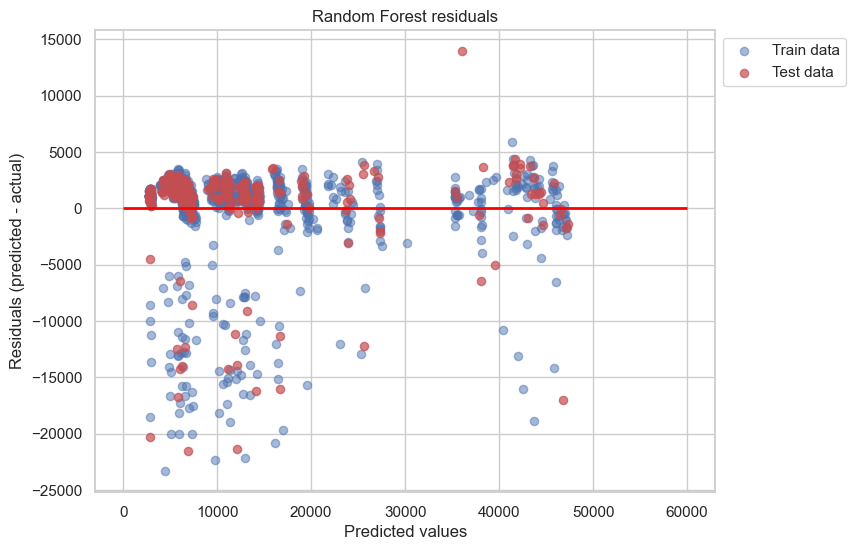

In [24]:
# Cross-validation gives averaged scores but no single set of predictions to
# plot, so for diagnostics we fit the forest on a conventional 80/20 hold-out
# split and inspect its residuals (prediction errors).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
print('Best RF params:', rf.named_steps['model'].best_params_)
print('R2 train: %.3f  |  R2 test: %.3f' % (
    metrics.r2_score(y_train, y_train_pred),
    metrics.r2_score(y_test, y_test_pred)))

# A healthy residual plot hovers around the zero line with no pattern.
# Train (blue) and test (red) clouds looking similar = little overfitting.
plt.figure(figsize=(8, 6))
plt.scatter(y_train_pred, y_train_pred - y_train,
            c='b', marker='o', s=35, alpha=0.5, label='Train data')
plt.scatter(y_test_pred, y_test_pred - y_test,
            c='r', marker='o', s=35, alpha=0.7, label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals (predicted - actual)')
plt.title('Random Forest residuals')
plt.hlines(y=0, xmin=0, xmax=60000, lw=2, color='red')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


Feature importance ranking

1. cat__smoker_yes (0.6977)
2. num__bmi (0.1789)
3. num__age (0.1163)
4. num__children (0.0063)
5. cat__region_southwest (0.0004)
6. cat__region_southeast (0.0002)
7. cat__sex_male (0.0002)
8. cat__region_northwest (0.0001)


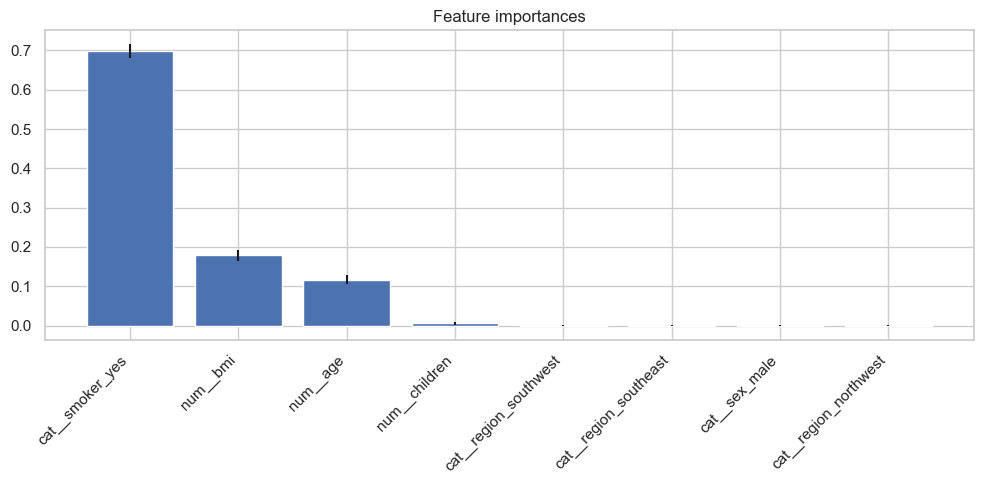

In [25]:
# Feature importances: a tree's importance for a feature is how much that
# feature's splits reduce prediction error, averaged over all 200 trees.
# Values sum to 1, so they read as relative shares of predictive power.
# The error bars show the standard deviation across the individual trees.
forest = rf.named_steps['model'].best_estimator_
feature_names = rf.named_steps['prep'].get_feature_names_out()

importances = pd.Series(forest.feature_importances_, index=feature_names).sort_values(ascending=False)
std = pd.Series(
    np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0),
    index=feature_names,
)[importances.index]

print('Feature importance ranking\n')
for rank, (name, value) in enumerate(importances.items(), start=1):
    print(f'{rank}. {name} ({value:.4f})')

plt.figure(figsize=(10, 5))
plt.bar(importances.index, importances.values, color='b', yerr=std.values, align='center')
plt.title('Feature importances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Polynomial Regression


In [26]:
# Polynomial regression: PolynomialFeatures expands the preprocessed features
# with all squares (age^2, bmi^2, ...) and pairwise products (bmi x smoker_yes,
# age x smoker_yes, ...), then an ordinary linear model is fit on top.
# The interaction terms are what let it capture "smoking multiplies the cost
# of high BMI", which a plain linear model cannot express.
#
# include_bias=False because LinearRegression already fits an intercept.
# Degree is kept at 2: higher degrees explode the feature count and overfit.
poly_reg = Pipeline([
    ('prep', make_preprocessor()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression()),
])
evaluate('Polynomial Regression (deg=2)', poly_reg)

Polynomial Regression (deg=2): R2=0.835 (+/- 0.039)  MAE=2,913  RMSE=4,834


Degree-2 polynomial features add squared terms and pairwise interactions (e.g. `age x smoker_yes`, `bmi x smoker_yes`) on top of the original features. This lets a linear model capture the strongly non-linear effect of smoking combined with BMI and age that the EDA plots revealed, which is why it outperforms the plain linear model by a wide margin.

In [27]:
# Final comparison: identical preprocessing and identical CV folds for every
# model, so the ranking is a like-for-like comparison (lower RMSE = better).
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.round({'R2 (CV mean)': 3, 'R2 (CV std)': 3, 'MAE': 0, 'RMSE': 0})

,Model,R2 (CV mean),R2 (CV std),MAE,RMSE
0,Random Forest,0.855,0.032,2536.0,4547.0
1,Polynomial Regression (deg=2),0.835,0.039,2913.0,4834.0
2,Linear Regression,0.740,0.058,4203.0,6077.0
3,Ridge Regression,0.740,0.058,4204.0,6077.0
4,Lasso Regression,0.740,0.057,4204.0,6078.0


In [28]:
# Actual vs predicted charges for the best model (the Random Forest fitted on
# the 80/20 hold-out split above) — a row-by-row sanity check of how close
# individual predictions land.
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': rf.predict(X_test).round(2)})
print(f"Best model by CV RMSE: {results_df.loc[0, 'Model']}")
comparison.head(15)

Best model by CV RMSE: Random Forest


,Actual,Predicted
764,9095.06825,9997.36
887,5272.17580,6174.18
890,29330.98315,27287.81
1293,9301.89355,10295.40
259,33750.29180,35274.27
1312,4536.25900,6449.75
899,2117.33885,2767.08
752,14210.53595,14266.28
1286,3732.62510,5261.46
707,10264.44210,11203.58


## Conclusion

As the EDA suggested, **smoking** is by far the strongest driver of medical charges (~70% of the Random Forest's predictive power), followed by **BMI** and **age**. The non-linear models — Random Forest and degree-2 Polynomial Regression — clearly outperform the plain linear models because the effect of smoking *interacts* with BMI and age, a pattern linear models cannot express. Regularization (Ridge/Lasso) barely helps here: the feature space is small and not strongly collinear, so there is little overfitting for it to fix.

These cross-validated numbers are reproduced by `InsurancePrediction.py`, which runs this exact pipeline end-to-end and saves the metrics table and figures to `results/`.